In [2]:
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

print(np.__file__)

/home/kchen/.local/lib/python3.10/site-packages/numpy/__init__.py


In [3]:
data_dir = "../../datasets"
hmc_table_path = os.path.join(data_dir, "taxonomic_table.csv")
hmc_df = pd.read_csv(hmc_table_path, nrows=50000)

In [3]:
# Show the first few rows
display(hmc_df.head())

# Show the shape of the dataframe
print("Shape:", hmc_df.shape)

# Show data types
print("Data types:\n", hmc_df.dtypes.value_counts())

# Show sum of each row (excluding the first two columns)
sums = hmc_df.iloc[:, 2:].sum(axis=1)
print("maximum sum:", sums.max(), "minimum sum:", sums.min())

# get how many nonzero values are in each row
nonzero_counts = (hmc_df.iloc[:, 2:] > 0).sum(axis=1)
nonzero_counts = np.array(nonzero_counts)
print("max nonzero counts:", nonzero_counts.max(), "min nonzero counts:", nonzero_counts.min())
print(nonzero_counts)




,Unnamed: 0,sample,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.NA,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Lactiplantibacillus,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus,...,Bacteria.Planctomycetota.Phycisphaerae.Phycisphaerales.Phycisphaeraceae.JL-ETNP-F27,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Microcystaceae.Crocosphaera,Bacteria.Pseudomonadota.Alphaproteobacteria.Rickettsiales.Rickettsiaceae.Candidatus Gigarickettsia,Bacteria.Bacillota.Bacilli.Bacillales.Bacillaceae.Streptohalobacillus,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Cyanobacteriaceae.Cyanobacterium PCC-10605,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Flavirhabdus,Bacteria.Pseudomonadota.Alphaproteobacteria.Rhodobacterales.Paracoccaceae.Octadecabacter,Bacteria.Pseudomonadota.Alphaproteobacteria.Acetobacterales.Acetobacteraceae.Swingsia,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Aurantiacicella,Archaea.Halobacteriota.Halobacteria.Halobacterales.Halobacteriaceae.Halocalculus
0,1,PRJDB10485_DRR243823,179,435,481,653,471,6,109,495,...,0,0,0,0,0,0,0,0,0,0
1,2,PRJDB10485_DRR243824,0,667,435,140,1798,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,PRJDB10485_DRR243825,0,2025,0,0,3651,0,0,34,...,0,0,0,0,0,0,0,0,0,0
3,4,PRJDB10485_DRR243826,0,1760,0,0,669,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,PRJDB10485_DRR243827,843,6937,366,4222,2166,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Shape: (10000, 4682)
Data types:
 int64     4681
object       1
Name: count, dtype: int64
maximum sum: 993123 minimum sum: 1
max nonzero counts: 265 min nonzero counts: 1
[55 60 48 ... 80 49 29]


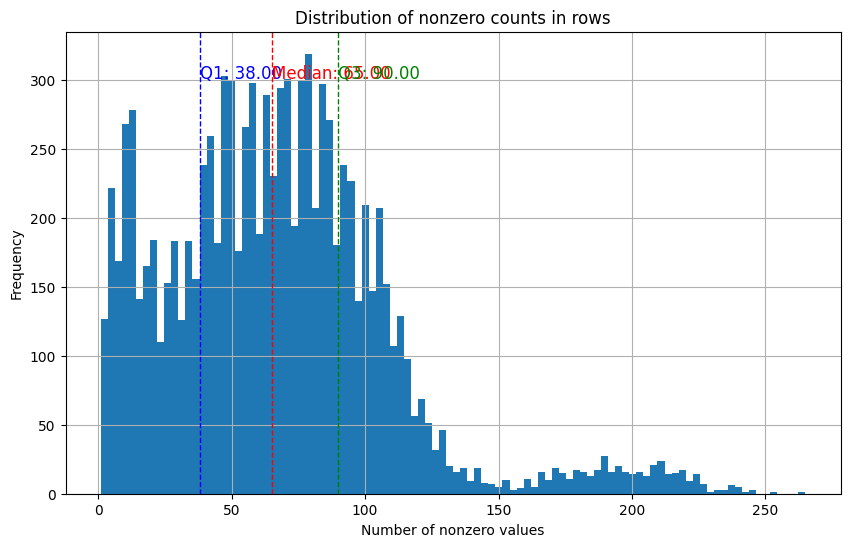

In [4]:
# plot nonzero counts
plt.figure(figsize=(10, 6))
plt.hist(nonzero_counts, bins=100)
plt.xlabel("Number of nonzero values")
plt.ylabel("Frequency")
plt.title("Distribution of nonzero counts in rows")

# add vertical line for median
median = np.median(nonzero_counts)
q25, q75 = np.percentile(nonzero_counts, [25, 75])

# Plot lines for quartiles and median
plt.axvline(q25, color='blue', linestyle='dashed', linewidth=1)
plt.axvline(median, color='red', linestyle='dashed', linewidth=1)
plt.axvline(q75, color='green', linestyle='dashed', linewidth=1)

# Add labels above the lines
plt.text(q25, plt.ylim()[1]*0.9, f'Q1: {q25:.2f}', color='blue', fontsize=12)
plt.text(median, plt.ylim()[1]*0.9, f'Median: {median:.2f}', color='red', fontsize=12)
plt.text(q75, plt.ylim()[1]*0.9, f'Q3: {q75:.2f}', color='green', fontsize=12)


plt.grid()
plt.show()

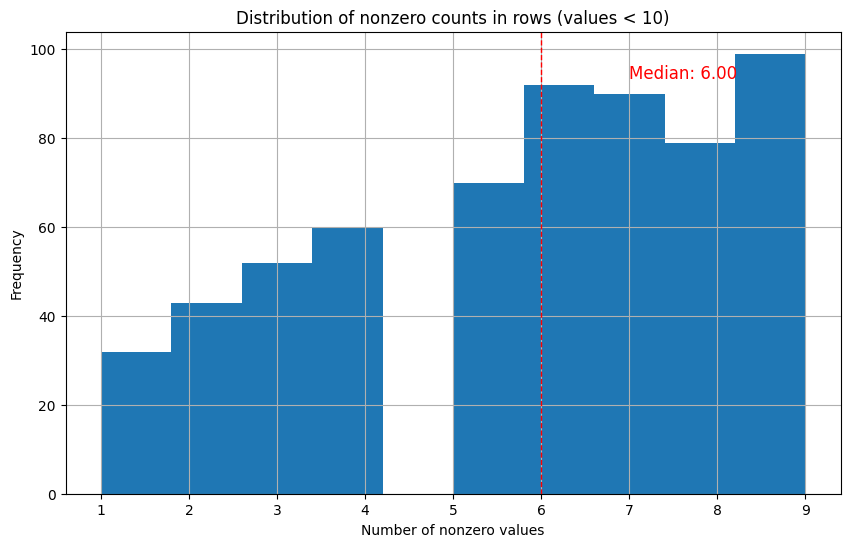

In [5]:
plt.figure(figsize=(10, 6))

# Filter values below n
n = 10
filtered_counts = nonzero_counts[nonzero_counts < n]

# Plot histogram with n bins
plt.hist(filtered_counts, bins=n)

plt.xlabel("Number of nonzero values")
plt.ylabel("Frequency")
plt.title(f"Distribution of nonzero counts in rows (values < {n})")

# Add vertical line for median of filtered values
median = np.median(filtered_counts)
plt.axvline(median, color='r', linestyle='dashed', linewidth=1)
plt.text(median + 1, plt.ylim()[1] * 0.9, f'Median: {median:.2f}', color='red', fontsize=12)

plt.grid()
plt.show()


In [6]:
import numpy as np

# Dummy input: 3 samples × 5 taxa
unprocessed_data = np.array([
    [1, 2, 9, 67, 1208, 1270, 0, 0],
    [1, 2, 9, 67, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 100]
])

# unprocessed_data = np.array([
#     [1,2,4],
#     [2,4,8]
# ])


# Assuming your function is part of a class, make a minimal dummy class for testing:
class Dummy:
    def clr_from_np(self, unprocessed_data):
        
        print("Not doing binning, only applying CLR transform to data!")
        clr_data = []

        for row in unprocessed_data:
            if row.max() == 0:
                raise ValueError("The data has all zero values, please check the data.")
            
            non_zero_mask = row > 0
            non_zero_values = row[non_zero_mask]
            
            log_non_zero = np.log(non_zero_values)
            geometric_mean_log = np.mean(log_non_zero)
            clr_non_zero = log_non_zero - geometric_mean_log

            epsilon = 1e-6
            row_min, row_max = clr_non_zero.min(), clr_non_zero.max()
            if row_max > row_min:
                clr_non_zero_scaled = ((clr_non_zero - row_min) / (row_max - row_min)) * (1 - epsilon) + epsilon
            else:
                clr_non_zero_scaled = np.full_like(clr_non_zero, fill_value=epsilon)
            
            clr_row = np.zeros_like(row, dtype=np.float64)
            clr_row[non_zero_mask] = clr_non_zero_scaled
            
            clr_data.append(clr_row)
        
        clr_array = np.stack(clr_data)
        return clr_array
    
    def closure_from_np(self, unprocessed_data):
        row_sums = unprocessed_data.sum(axis=1, keepdims=True)
        closed_data = unprocessed_data / row_sums
        return closed_data
    
    def clrplus_from_np(self, unprocessed_data):
        clr_data = self.clr_from_np(unprocessed_data)
        
        # Apply log1p(exp(x)) only to nonzeros
        nonzero_mask = clr_data != 0
        clr_plus_data = clr_data.copy()
        clr_plus_data[nonzero_mask] = np.log1p(np.exp(clr_data[nonzero_mask]))
        return clr_plus_data
    
    
    def clrplus_from_np2(self, unprocessed_data):
        print("Not doing binning, only applying CLR plus 1 transform to data!")
        clr_data = []

        for row in unprocessed_data:
            if row.max() == 0:
                raise ValueError("The data has all zero values, please check the data.")
            
            non_zero_mask = row > 0
            non_zero_values = row[non_zero_mask]
            
            log_non_zero = np.log(non_zero_values)
            geometric_mean_log = np.mean(log_non_zero)
            clr_non_zero = log_non_zero - geometric_mean_log
            
            epsilon = 1e-6

            if clr_non_zero.size > 0:
                clr_non_zero_scaled = np.log1p(np.exp(clr_non_zero))
            else:
                clr_non_zero_scaled = np.full_like(clr_non_zero, fill_value=epsilon)
            
            clr_row = np.zeros_like(row, dtype=np.float64)
            clr_row[non_zero_mask] = clr_non_zero_scaled
            
            clr_data.append(clr_row)
        
        clr_array = np.stack(clr_data)
        return clr_array
# Run the test
clr_data = Dummy().clr_from_np(unprocessed_data)
print("\nInput data:\n", unprocessed_data)
print("\nCLR-transformed data:\n", clr_data)

clr_plus_data = Dummy().clrplus_from_np(unprocessed_data)
print("\nCLR exp +1 -transformed data:\n", clr_plus_data)

clr_plus_data = Dummy().clrplus_from_np2(unprocessed_data)
print("\nCLR exp +1 -transformed data:\n", clr_plus_data)


Not doing binning, only applying CLR transform to data!

Input data:
 [[   1    2    9   67 1208 1270    0    0]
 [   1    2    9   67    0    0    0    0]
 [   0    0    0    0    0    0    0  100]]

CLR-transformed data:
 [[1.00000000e-06 9.69883490e-02 3.07443622e-01 5.88334909e-01
  9.92996733e-01 1.00000000e+00 0.00000000e+00 0.00000000e+00]
 [1.00000000e-06 1.64851692e-01 5.22565330e-01 1.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 1.00000000e-06]]
Not doing binning, only applying CLR transform to data!

CLR exp +1 -transformed data:
 [[0.69314768 0.74281674 0.85863795 1.02997189 1.30814672 1.31326169
  0.         0.        ]
 [0.69314768 0.7789662  0.9881827  1.31326169 0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.69314768]]
Not doing binning, only applying CLR plus 1 tran

In [7]:
import sys
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import anndata as ad

# Adjust this depending on where your notebook lives
sys.path.append(os.path.abspath("../.."))
from data_utils.graph_helpers import *

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
get_valid_name(["a", "NA", "NA", "b", "c"])

(['a', 'b', 'c'], [3, 1], False)

In [9]:
ann_taxa = ad.read_h5ad("/home/kchen/microbiome/gut_microbiome_GPT/datasets/remove_redundant_oct24/finetune_test.h5ad")
taxa = ann_taxa.var_names.tolist()

/home/kchen/miniconda3/envs/hmbGPT/lib/python3.10/site-packages/anndata/_core/anndata.py:1756: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
iter = ann_taxa.varm["taxonomy"].iterrows()

next(iter)[1].to_list()

['Bacteria',
 'Actinomycetota',
 'Coriobacteriia',
 'Coriobacteriales',
 'Atopobiaceae',
 'Tractidigestivibacter']

In [11]:
lens = [len(get_valid_name(a[1].to_list())[0]) for a in ann_taxa.varm["taxonomy"].iterrows()]

from collections import Counter
counts = Counter(lens)

for num, count in counts.items():
    print(f"{num}: {count}")
    

6: 3216
5: 563
4: 345
3: 114
2: 54
1: 3
0: 1


In [12]:
# Now print examples where the valid chain length == 2
print("\nExamples with valid chain length = 2:\n")

for (idx, row), l in zip(ann_taxa.varm["taxonomy"].iterrows(), lens):
    if l == 2:
        valid_chain, _, _ = get_valid_name(row.to_list())
        print(f"{idx}: {valid_chain}")


Examples with valid chain length = 2:

Bacteria.Bacillota.NA.NA.NA.NA: ['Bacteria', 'Bacillota']
Bacteria.Pseudomonadota.NA.NA.NA.NA: ['Bacteria', 'Pseudomonadota']
Bacteria.Thermodesulfobacteriota.NA.NA.NA.NA: ['Bacteria', 'Thermodesulfobacteriota']
Bacteria.Actinomycetota.NA.NA.NA.NA: ['Bacteria', 'Actinomycetota']
Bacteria.Verrucomicrobiota.NA.NA.NA.NA: ['Bacteria', 'Verrucomicrobiota']
Bacteria.Incertae Sedis.Incertae Sedis.SJA-28.Incertae Sedis.Incertae Sedis: ['Bacteria', 'SJA-28']
Bacteria.FCPU426.Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis: ['Bacteria', 'FCPU426']
Bacteria.NKB15.Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis: ['Bacteria', 'NKB15']
Bacteria.Armatimonadota.Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis: ['Bacteria', 'Armatimonadota']
Bacteria.Latescibacterota.Incertae Sedis.Incertae Sedis.Incertae Sedis.Incertae Sedis: ['Bacteria', 'Latescibacterota']
Bacteria.Patescibacteria.NA.NA.NA.NA: ['Bacteria', 'Patescibacteria']


In [13]:
np.nonzero(np.array([[1, 2, 0], [3,0,0]]))[0]

array([0, 0, 1])

In [8]:
new_hmc_df = hmc_df.drop(columns="Unnamed: 0")
new_hmc_df

,sample,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Atopobiaceae.Tractidigestivibacter,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Coriobacteriaceae.Collinsella,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Adlercreutzia,Bacteria.Actinomycetota.Coriobacteriia.Coriobacteriales.Eggerthellaceae.Senegalimassilia,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.Holdemanella,Bacteria.Bacillota.Bacilli.Erysipelotrichales.Erysipelotrichaceae.NA,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Lactiplantibacillus,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Limosilactobacillus,Bacteria.Bacillota.Bacilli.Lactobacillales.Lactobacillaceae.Pediococcus,...,Bacteria.Planctomycetota.Phycisphaerae.Phycisphaerales.Phycisphaeraceae.JL-ETNP-F27,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Microcystaceae.Crocosphaera,Bacteria.Pseudomonadota.Alphaproteobacteria.Rickettsiales.Rickettsiaceae.Candidatus Gigarickettsia,Bacteria.Bacillota.Bacilli.Bacillales.Bacillaceae.Streptohalobacillus,Bacteria.Cyanobacteriota.Cyanobacteriia.Cyanobacteriales.Cyanobacteriaceae.Cyanobacterium PCC-10605,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Flavirhabdus,Bacteria.Pseudomonadota.Alphaproteobacteria.Rhodobacterales.Paracoccaceae.Octadecabacter,Bacteria.Pseudomonadota.Alphaproteobacteria.Acetobacterales.Acetobacteraceae.Swingsia,Bacteria.Bacteroidota.Bacteroidia.Flavobacteriales.Flavobacteriaceae.Aurantiacicella,Archaea.Halobacteriota.Halobacteria.Halobacterales.Halobacteriaceae.Halocalculus
0,PRJDB10485_DRR243823,179,435,481,653,471,6,109,495,56,...,0,0,0,0,0,0,0,0,0,0
1,PRJDB10485_DRR243824,0,667,435,140,1798,0,0,0,172,...,0,0,0,0,0,0,0,0,0,0
2,PRJDB10485_DRR243825,0,2025,0,0,3651,0,0,34,0,...,0,0,0,0,0,0,0,0,0,0
3,PRJDB10485_DRR243826,0,1760,0,0,669,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,PRJDB10485_DRR243827,843,6937,366,4222,2166,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,PRJNA304948_SRR2984561,0,0,0,0,1107,0,7,0,0,...,0,0,0,0,0,0,0,0,0,0
49996,PRJNA304948_SRR2984562,53,134,7,19,459,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49997,PRJNA304948_SRR2984563,0,713,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
49998,PRJNA304948_SRR2984564,0,385,0,0,0,0,66,20,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
import pandas as pd

# Assuming df is your dataframe and the first column is named "sample"
# Extract study prefix (everything before first "_")
new_hmc_df['study'] = new_hmc_df['sample'].str.split('_').str[0]

# Compute number of studies
num_studies = new_hmc_df['study'].nunique()

# Compute nonzero counts per sample (excluding 'sample' and 'study' columns)
feature_cols = new_hmc_df.columns.difference(['sample', 'study'])
nonzero_counts = (new_hmc_df[feature_cols] != 0).sum(axis=1)

# Average nonzeros per study
avg_nonzeros_per_study = (
    pd.DataFrame({'study': new_hmc_df['study'], 'nonzeros': nonzero_counts})
    .groupby('study')['nonzeros']
    .mean()
)

print(f"Number of unique studies: {num_studies}")
print("\nAverage number of nonzero taxa per study:")
print(avg_nonzeros_per_study)


Number of unique studies: 124

Average number of nonzero taxa per study:
study
PRJDB10485      48.376147
PRJDB10527      96.648352
PRJDB10528      51.221875
PRJDB10612      38.213675
PRJDB11845      73.640777
                  ...    
PRJNA297510     26.593750
PRJNA297793    117.000000
PRJNA298590     39.291513
PRJNA301903      6.564516
PRJNA304948     67.710611
Name: nonzeros, Length: 124, dtype: float64


In [11]:
import pandas as pd

# Assume df['study'] already exists and 'sample' is the first column
feature_cols = new_hmc_df.columns.difference(['sample', 'study'])

# Group by study and aggregate with max to check if a taxon is ever present
study_aggregated = new_hmc_df.groupby('study')[feature_cols].max()

# Count how many taxa are represented (nonzero in at least one sample)
represented_taxa = (study_aggregated > 0).sum(axis=1)

print("Number of represented taxa per study:")
print(represented_taxa)

print(f"\nNumber of unique studies: {len(represented_taxa)}")


Number of represented taxa per study:
study
PRJDB10485     369
PRJDB10527     397
PRJDB10528     374
PRJDB10612     209
PRJDB11845     382
              ... 
PRJNA297510    164
PRJNA297793    305
PRJNA298590    294
PRJNA301903    130
PRJNA304948    516
Length: 124, dtype: int64

Number of unique studies: 124


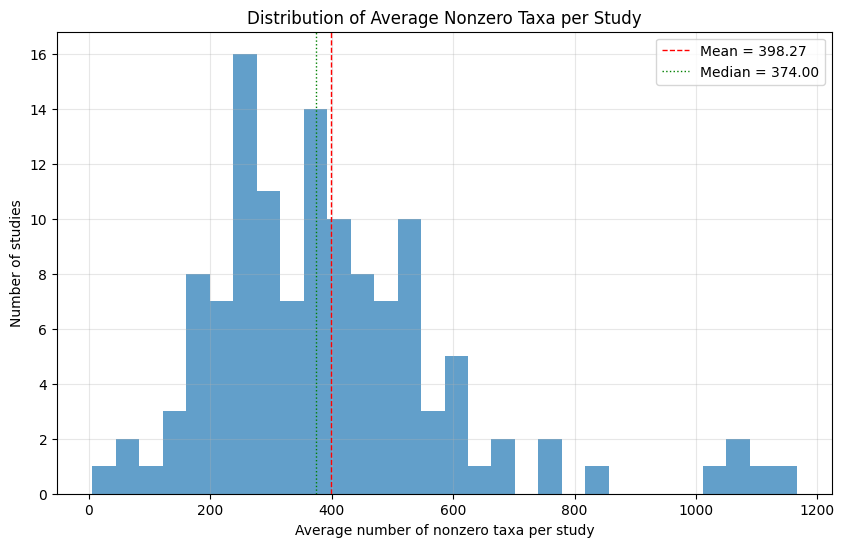

In [12]:
mean_val = represented_taxa.mean()
median_val = represented_taxa.median()

plt.figure(figsize=(10, 6))
plt.hist(represented_taxa, bins=30, alpha=0.7)
plt.axvline(mean_val, color='r', linestyle='dashed', linewidth=1, label=f'Mean = {mean_val:.2f}')
plt.axvline(median_val, color='g', linestyle='dotted', linewidth=1, label=f'Median = {median_val:.2f}')
plt.xlabel("Average number of nonzero taxa per study")
plt.ylabel("Number of studies")
plt.title("Distribution of Average Nonzero Taxa per Study")
plt.legend()
plt.grid(alpha=0.3)
plt.show()